In [2]:
import pandas as pd

Membuat dataframe ocean land

In [4]:
xls = "dataset\Dataset Bersih Lengkap.xlsx"
df_land = pd.read_excel(xls, sheet_name="Land Logistics")
df_land.columns = df_land.columns.str.strip().str.lower().str.replace(" ", "_")

df_land['fixed_cost'] = (
    df_land['fixed_cost'].astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df_land_edges = df_land[[
    'dc_id', 'destination_(city)', 'type', 'volume', 'fixed_cost'
]].rename(columns={
    'dc_id': 'from_dc',
    'destination_(city)': 'to_area',
    'type': 'mode',
    'volume': 'volume_cbm',
    'fixed_cost': 'cost_idr'
})

df_land_edges.head()

,from_dc,to_area,mode,volume_cbm,cost_idr
0,DC031,Denpasar,Build Up (40 CBM),1600,12500000.0
1,DC031,Denpasar,FUSO (22 CBM),880,8682800.0
2,DC033,Lombok,Build Up (40 CBM),1600,23500000.0
3,DC033,Lombok,CDD (7 CBM),280,13000000.0
4,DC033,Lombok,FUSO (22 CBM),880,17500000.0


In [5]:
df_ocean = pd.read_excel(
    xls, 
    sheet_name="Ocean Freight",
    dtype=str  # ⬅️ ini penting: baca semua kolom sebagai string!
)
print(df_ocean.columns.tolist())
df_ocean.head()



df_ocean['fixed_cost_clean'] = pd.to_numeric(df_ocean['Fixed Cost'], errors='coerce').fillna(0).round(0)
df_ocean.head()

df_ocean_clean = df_ocean[[
    'DC ID', 'Destination (City)', 'Type', 'Volume', 'fixed_cost_clean'
]].rename(columns={
    'DC ID': 'from_dc',
    'Destination (City)': 'to_area',
    'Type': 'mode',
    'Volume': 'volume_cbm',
    'fixed_cost_clean': 'cost_idr'
})

print(df_ocean_clean[['from_dc', 'to_area', 'mode', 'cost_idr']].sample(5))


['DC ID', 'Carrier Provider', 'Fixed Cost', 'Variable Cost', 'Destination (City)', 'Customer Code', 'Customer Name', 'Type', 'Volume']
   from_dc       to_area  mode    cost_idr
4    DC039         Berau  20FT  17082458.0
12   DC041  Palangkaraya  20FT  13705881.0
14   DC036          Palu  20FT  10850000.0
6    DC032       Kendari  20FT  17200000.0
13   DC041  Palangkaraya  40FT  22539849.0


Gabungin ocean land tahap 1

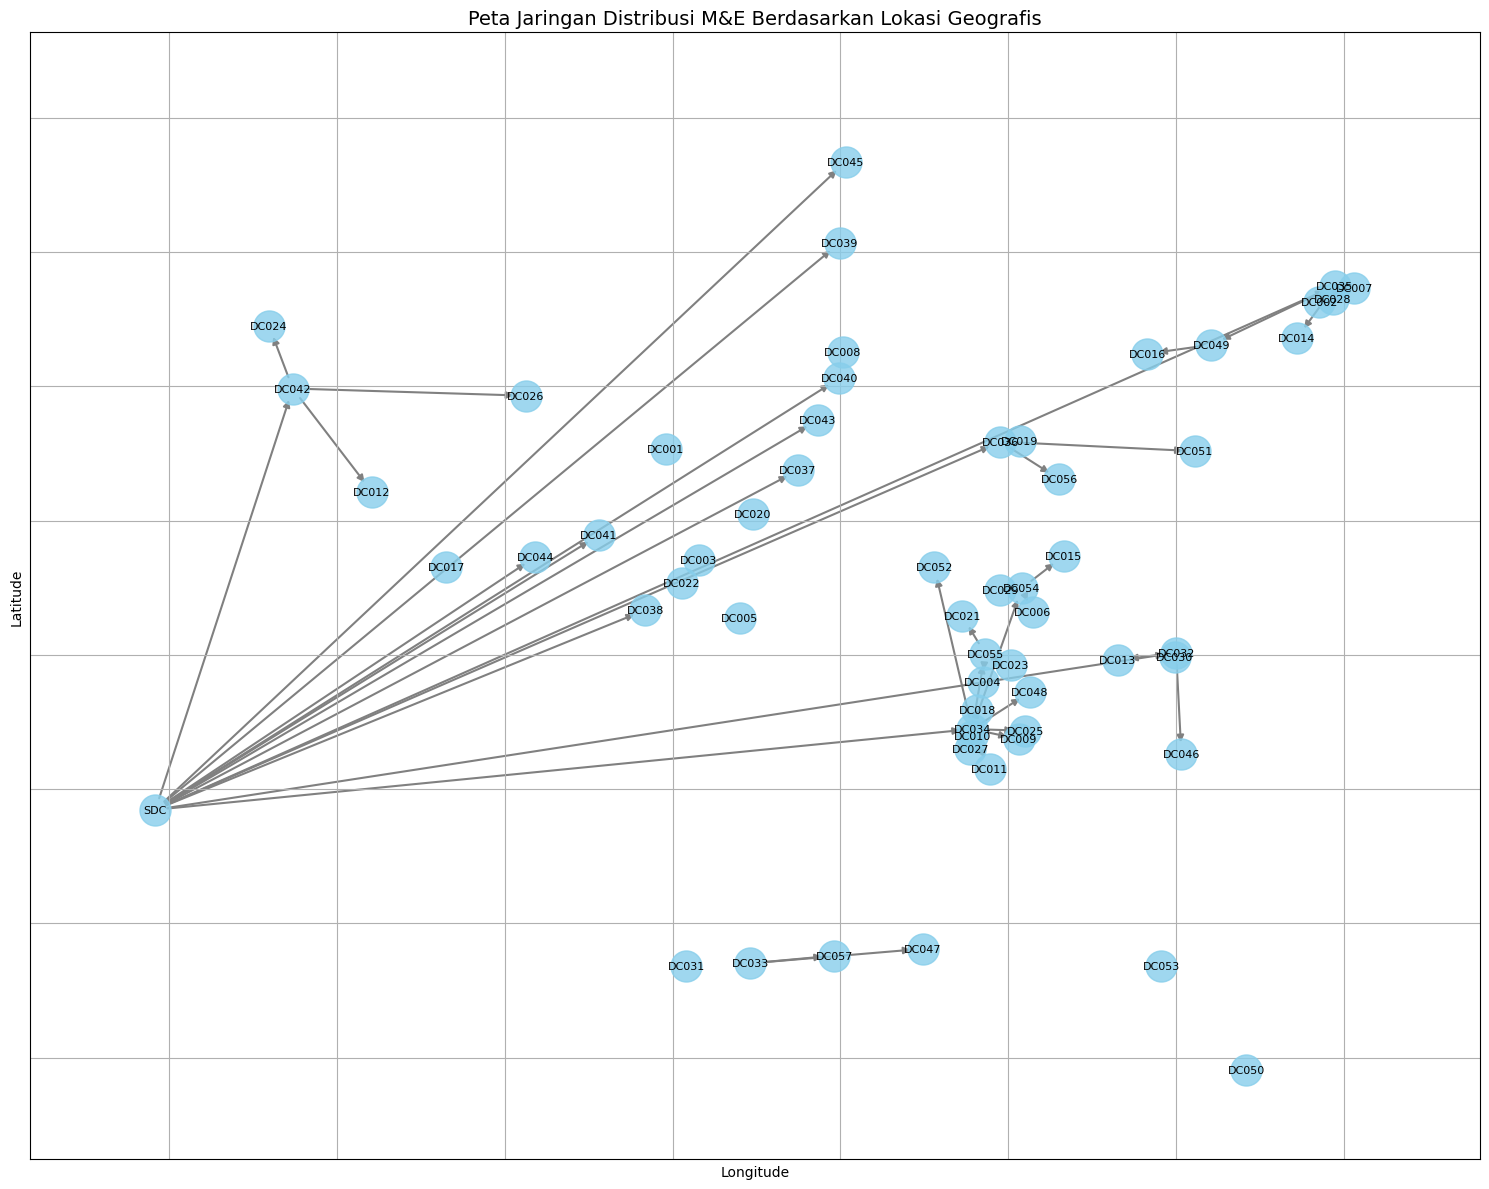

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# --- STEP 1: Load Dataset ---
xls = pd.ExcelFile("dataset/1742574481558_Dataset-ME-2025.xlsx")
df_dc = pd.read_excel(xls, sheet_name="DC Final")

# --- STEP 2: Preprocessing df_node (semua DC) ---
df_dc.columns = df_dc.columns.str.strip().str.lower().str.replace(" ", "_")

df_node = df_dc[[
    'dc_id', 'type', 'area', 'distributor_area', 'latitude', 'longitude', 'sent_from'
]].dropna(subset=['dc_id', 'latitude', 'longitude'])

df_node = df_node.rename(columns={
    'dc_id': 'node_id',
    'type': 'node_type',
    'area': 'location_name',
    'distributor_area': 'region'
})

# Pastikan latitude & longitude numerik
df_node['latitude'] = df_node['latitude'].astype(str).str.replace(',', '.').astype(float)
df_node['longitude'] = df_node['longitude'].astype(str).str.replace(',', '.').astype(float)

# --- STEP 3: Bangun Graph G ---
G = nx.DiGraph()

# Tambah node
for _, row in df_node.iterrows():
    G.add_node(
        row['node_id'],
        label=row['node_id'],
        type=row['node_type'],
        pos=(row['longitude'], row['latitude'])
    )

# --- Tambahkan node SDC Karawang secara manual ---
karawang_lat = -6.305384
karawang_lon = 107.296913

G.add_node(
    'SDC',
    label='SDC',
    type='Pabrik',
    pos=(karawang_lon, karawang_lat)
)

# --- STEP 4: Buat Dataframe Edge dari sent_from ---
# Map lokasi asal (sent_from) → node_id
location_to_node = dict(zip(df_node['location_name'], df_node['node_id']))

df_edges = df_node[df_node['sent_from'].notna()][['node_id', 'sent_from']].copy()
df_edges = df_edges.rename(columns={'node_id': 'to_node', 'sent_from': 'from_node'})
df_edges['from_node'] = df_edges['from_node'].map(location_to_node)

# Drop baris yang mapping-nya gagal
df_edges = df_edges.dropna(subset=['from_node'])

# Tambah edge ke graf
for _, row in df_edges.iterrows():
    G.add_edge(row['from_node'], row['to_node'])

# Tambahkan edge dari Karawang ke node yang sent_from-nya 'SDC'
karawang_children = df_node[df_node['sent_from'] == 'SDC']['node_id'].tolist()

for to_node in karawang_children:
    G.add_edge('SDC', to_node)


# --- STEP 5: Gambar Peta Jaringan Distribusi ---
pos_geo = {node: data['pos'] for node, data in G.nodes(data=True)}

plt.figure(figsize=(15, 12))

# Gambar node
nx.draw_networkx_nodes(
    G, pos_geo, 
    node_color='skyblue', 
    node_size=500, 
    alpha=0.8
)

# Gambar edge (panah antar DC)
nx.draw_networkx_edges(
    G, pos_geo, 
    edge_color='gray', 
    arrows=True,
    width=1.5
)

# Tambahkan label node
labels = {node: G.nodes[node]['label'] for node in G.nodes}
nx.draw_networkx_labels(
    G, pos_geo, labels,
    font_size=8
)

plt.title("Peta Jaringan Distribusi M&E Berdasarkan Lokasi Geografis", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.axis('equal')  # supaya bentuk geografis tidak melebar
plt.tight_layout()
plt.show()


In [7]:
df_edges = pd.concat([df_land_edges, df_ocean_clean], ignore_index=True)
def classify_mode(mode_str):
    if pd.isna(mode_str):
        return 'Unknown'
    mode_str = str(mode_str).upper()
    if 'FT' in mode_str:
        return 'Ocean'
    return 'Land'

df_edges['mode_type'] = df_edges['mode'].apply(classify_mode)
df_edges.sample(5)



,from_dc,to_area,mode,volume_cbm,cost_idr,mode_type
24,DC043,Samarinda,40FT,2360,23263192.0,Ocean
5,DC037,Balikpapan,20FT,1160,11214769.0,Ocean
20,DC036,Palu,40FT,2360,17250000.0,Ocean
22,DC042,Pontianak,40FT,2360,17943460.0,Ocean
17,DC041,Palangkaraya,20FT,1160,13705881.0,Ocean


Membuat ocean land final

In [8]:
df_oceanland = df_edges.copy()

# Rename untuk konsistensi
df_oceanland = df_oceanland.rename(columns={
    'from_dc': 'target_node',
    'mode': 'moda',
    'cost_idr': 'cost_per_trip',
    'volume_cbm': 'volume_per_trip'
})

# Tambahkan kolom source_node sebagai SDC
df_oceanland['source_node'] = 'SDC'  # atau nama ID pabrikmu


# Ambil kolom penting untuk df_edges_final
df_oceanland = df_oceanland[['source_node', 'target_node', 'moda', 'cost_per_trip', 'volume_per_trip']]

# Rename untuk konsistensi
df_oceanland = df_oceanland.rename(columns={
    'from_dc': 'target_node',
    'moda': 'mode_type',
    'cost_idr': 'cost_per_trip',
    'volume_cbm': 'volume_per_trip'
})

df_oceanland.head()

,source_node,target_node,mode_type,cost_per_trip,volume_per_trip
0,SDC,DC031,Build Up (40 CBM),12500000.0,1600
1,SDC,DC031,FUSO (22 CBM),8682800.0,880
2,SDC,DC033,Build Up (40 CBM),23500000.0,1600
3,SDC,DC033,CDD (7 CBM),13000000.0,280
4,SDC,DC033,FUSO (22 CBM),17500000.0,880


Membuat rute middle mile

In [9]:
import pandas as pd
from geopy.distance import geodesic

# 1. Load data
file_path = "dataset/E2099100.xlsx"
df_middle = pd.read_excel(file_path, sheet_name="Middle Mile")

# 2. Convert kolom koordinat ke float
coord_cols = ['Origin Latitude', 'Longitude_x', 'Destination Latitude', 'Destination Longitude']
for col in coord_cols:
    df_middle[col] = pd.to_numeric(df_middle[col], errors='coerce')  # coerce biar error jadi NaN


df_middle.sample(10)

,Distributor Area,Origin Area,Origin Latitude,Longitude_x,Destination Area,Destination Latitude,Destination Longitude,Volume (CS)
631,Sulawesi,Polman,-3.420450,119.316940,Mangkutana,-2.525350,120.824050,50
517,Sulawesi,Kolaka,-4.076710,121.635070,Marisa,0.486710,122.070340,50
841,Sulawesi,Bau-Bau,-5.481590,122.580000,Jeneponto,-5.701040,119.721470,100
385,Sulawesi,Amurang,1.255330,124.631870,Pangkep,-4.816450,119.541930,50
202,Kalimantan,Tarakan,3.343070,117.576925,Sintang,-0.137800,112.810600,100
162,Kalimantan,Palangkaraya,-2.218321,113.900455,Sintang,-0.137800,112.810600,100
163,Kalimantan,Pontianak,-0.031090,109.342500,Ampah - Teweh,-0.935414,114.901123,100
114,Kalimantan,Balikpapan,-1.249963,116.868785,Barabai,-2.581936,115.390569,100
892,Sulawesi,Gorontalo,0.620050,123.023680,Tomohon,1.297120,124.836200,100
59,Kalimantan,Ketapang,-1.569800,110.521500,Ampah - Teweh,-0.935414,114.901123,50


In [10]:
# 3. Drop baris yang koordinatnya tidak valid
df_middle_cleaned = df_middle.dropna(subset=coord_cols)

# 4. Hitung jarak
df_middle_cleaned['distance_km'] = df_middle_cleaned.apply(
    lambda row: geodesic(
        (row['Origin Latitude'], row['Longitude_x']),
        (row['Destination Latitude'], row['Destination Longitude'])
    ).km,
    axis=1
)
df_middle_cleaned['distance_km'] = df_middle_cleaned['distance_km'].round(2)

# 5. Lihat hasil
print(df_middle_cleaned[['Origin Area', 'Destination Area', 'distance_km']].sample(10))


    Origin Area Destination Area  distance_km
437      Bitung        Jeneponto       996.79
833        Palu           Toraja       243.93
192      Sampit          Sintang       266.00
883   Gorontalo       Kotamobagu       142.67
566      Marisa            Barru       605.81
571      Marisa        Jeneponto       732.34
678      Sinjai           Unaaha       275.11
561  Mangkutana          Takalar       352.95
704     Tomohon        Jeneponto       960.28
859        Bone        Bulukumba        79.63


C:\Users\nesha\AppData\Local\Temp\ipykernel_6896\1122828425.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_middle_cleaned['distance_km'] = df_middle_cleaned.apply(
C:\Users\nesha\AppData\Local\Temp\ipykernel_6896\1122828425.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_middle_cleaned['distance_km'] = df_middle_cleaned['distance_km'].round(2)


In [11]:
# Merge df_node dengan df_edges
df_dc_olCost = df_node.merge(
    df_edges,
    left_on='node_id',
    right_on='from_dc',
    how='left'
)

# Drop kolom 'from_dc' dan 'to_area' dari hasil merge
df_dc_olCost = df_dc_olCost.drop(columns=['from_dc', 'to_area'])

# Cek hasil
df_dc_olCost.sample(10)



,node_id,node_type,location_name,region,latitude,longitude,sent_from,mode,volume_cbm,cost_idr,mode_type
60,DC047,Indirect DC,BIMA,BCP Outer,-8.37759,118.725640,Lombok,NaN,NaN,NaN,NaN
41,DC036,Direct CPU,Palu,BCP Outer,-0.82320,119.885150,SDC,20FT,1160,10850000.0,Ocean
57,DC045,Direct DC,Tarakan,Kalimantan,3.34307,117.576925,SDC,20FT,1160,17927384.0,Ocean
27,DC028,Depo,Tomohon,BCP Outer,1.29712,124.836200,Manado,NaN,NaN,NaN,NaN
9,DC010,Depo,Gowa,BCP Outer,-5.20514,119.463740,Makassar,NaN,NaN,NaN,NaN
10,DC011,Depo,Jeneponto,BCP Outer,-5.70104,119.721470,Makassar,NaN,NaN,NaN,NaN
11,DC012,Depo,Ketapang,Kalimantan,-1.56980,110.521500,Pontianak,NaN,NaN,NaN,NaN
3,DC004,Depo,Barru,BCP Outer,-4.40562,119.618770,Pare-Pare,NaN,NaN,NaN,NaN
52,DC042,Direct DC,Pontianak,Kalimantan,-0.03109,109.342500,SDC,40FT,2360,17943460.0,Ocean
65,DC052,Indirect DC,Mamuju,BCP Outer,-2.68747,118.898640,Makassar,NaN,NaN,NaN,NaN


In [12]:
import pandas as pd

# Step 1: Buat mapping location_name → DC ID
location_to_dc_id = df_dc_olCost.set_index('location_name')['node_id'].to_dict()

# Step 2: Salin df_middle_cleaned biar tidak ubah yang asli
df_middle_edges = df_middle_cleaned.copy()

# Step 3: Mapping ke DC ID
df_middle_edges['origin_id'] = df_middle_edges['Origin Area'].map(location_to_dc_id)
df_middle_edges['destination_id'] = df_middle_edges['Destination Area'].map(location_to_dc_id)

# Step 4: Cek mapping yang gagal
missing_origin = df_middle_edges[df_middle_edges['origin_id'].isna()]
missing_dest = df_middle_edges[df_middle_edges['destination_id'].isna()]

print("🚨 Origin Area yang tidak ditemukan:")
print(missing_origin[['Origin Area']].drop_duplicates())

print("\n🚨 Destination Area yang tidak ditemukan:")
print(missing_dest[['Destination Area']].drop_duplicates())

# Step 5: Drop baris yang tidak berhasil mapping
df_middle_edges_cleaned = df_middle_edges.dropna(subset=['origin_id', 'destination_id']).copy()

# Step 6: Buat edge list final
df_middle_edge_list = df_middle_edges_cleaned[[
    'origin_id',
    'destination_id',
    'distance_km',
    'Volume (CS)'  # atau 'volume_cbm' tergantung kolom kamu
]].rename(columns={
    'distance_km': 'distance_km',
    'Volume (CS)': 'max_volume'
})

print("\n✅ Contoh edge list middle mile:")
print(df_middle_edge_list.sample(5))


🚨 Origin Area yang tidak ditemukan:
Empty DataFrame
Columns: [Origin Area]
Index: []

🚨 Destination Area yang tidak ditemukan:
Empty DataFrame
Columns: [Destination Area]
Index: []

✅ Contoh edge list middle mile:
    origin_id destination_id  distance_km max_volume
76      DC017          DC026       310.71         50
673     DC025          DC021       215.66         50
147     DC040          DC012       797.30        100
518     DC013          DC018       246.29         50
471     DC010          DC004        90.07         50


In [13]:
df_middle_edge_list.head()

,origin_id,destination_id,distance_km,max_volume
0,DC031,DC033,105.38,1000
1,DC033,DC031,105.38,1000
2,DC031,DC047,388.99,500
3,DC031,DC050,932.41,500
4,DC031,DC053,778.61,500


In [14]:
df_resources = pd.read_excel("dataset/1742574481558_Dataset-ME-2025.xlsx", sheet_name="Resources", skiprows=3)

# Rename
df_resources.columns = [
    "Region", "Branch",
    "CDD", "CDE", "GrandMax", "Kijang",
    "Unused1",
    "Driver", "Staff",
    "CDD Cost", "CDE Cost", "GrandMax Cost", "Kijang Cost", "Driver Cost", "Staff Cost",
    "CDD Total", "CDE Total", "GrandMax Total", "Kijang Total", "Driver Total",
    "Unused2",
    "Fleet Fixed Cost/Day", "Fleet Variable Cost/Day", "People Cost/Day",
    "Transport All In/Day", "Capacity"
]

# Drop kolom yang tidak dipakai
df_resources.drop(columns=["Unused1", "Unused2"], inplace=True)

# Pastikan kolom numerik jadi float
numeric_cols = df_resources.columns.difference(["Region", "Branch"])
df_resources[numeric_cols] = df_resources[numeric_cols].fillna(0).astype(float)

df_resources.head()


,Region,Branch,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,...,CDD Total,CDE Total,GrandMax Total,Kijang Total,Driver Total,Fleet Fixed Cost/Day,Fleet Variable Cost/Day,People Cost/Day,Transport All In/Day,Capacity
0,BNT,Bima,0.0,2.0,0.0,0.0,3.0,3.0,6900000.0,5500000.0,...,0.0,11000000.0,0.0,0.0,11269866.0,4.230769e+05,400000.0,4.334564e+05,1.256533e+06,400.0
1,BNT,Lombok,1.0,6.0,1.0,0.0,18.0,9.0,6900000.0,5500000.0,...,6900000.0,33000000.0,3500000.0,0.0,67619196.0,1.669231e+06,1600000.0,2.600738e+06,5.869969e+06,1600.0
2,BNT,Kupang,3.0,2.0,0.0,0.0,8.0,4.0,6900000.0,5500000.0,...,20700000.0,11000000.0,0.0,0.0,30052976.0,1.219231e+06,1000000.0,1.155884e+06,3.375114e+06,1240.0
3,BNT,Sumbawa,0.0,1.0,1.0,0.0,4.0,3.0,6900000.0,5500000.0,...,0.0,5500000.0,3500000.0,0.0,15026488.0,3.461538e+05,400000.0,5.779418e+05,1.324096e+06,320.0
4,BNT,Maumere,2.0,2.0,0.0,0.0,5.0,3.0,6900000.0,5500000.0,...,13800000.0,11000000.0,0.0,0.0,18783110.0,9.538462e+05,800000.0,7.224273e+05,2.476273e+06,960.0


In [15]:
# 1. Buat salinan kolom yang akan dibandingkan
df_resources['Branch_lower'] = df_resources['Branch'].str.lower().str.strip()
df_dc['Area_lower'] = df_dc['area'].str.lower().str.strip()

# 2. Merge pakai versi lowercase
df_resources_joined = df_resources.merge(
    df_dc[['Area_lower', 'dc_id']],
    left_on='Branch_lower',
    right_on='Area_lower',
    how='left'
)

# 3. Drop kolom bantu kalau sudah tidak dipakai
df_resources_joined.drop(columns=['Branch_lower', 'Area_lower'], inplace=True)

# 4. Lihat hasil join
df_resources_joined.head()


,Region,Branch,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,...,CDE Total,GrandMax Total,Kijang Total,Driver Total,Fleet Fixed Cost/Day,Fleet Variable Cost/Day,People Cost/Day,Transport All In/Day,Capacity,dc_id
0,BNT,Bima,0.0,2.0,0.0,0.0,3.0,3.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,11269866.0,4.230769e+05,400000.0,4.334564e+05,1.256533e+06,400.0,DC047
1,BNT,Lombok,1.0,6.0,1.0,0.0,18.0,9.0,6900000.0,5500000.0,...,33000000.0,3500000.0,0.0,67619196.0,1.669231e+06,1600000.0,2.600738e+06,5.869969e+06,1600.0,DC033
2,BNT,Kupang,3.0,2.0,0.0,0.0,8.0,4.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,30052976.0,1.219231e+06,1000000.0,1.155884e+06,3.375114e+06,1240.0,DC050
3,BNT,Sumbawa,0.0,1.0,1.0,0.0,4.0,3.0,6900000.0,5500000.0,...,5500000.0,3500000.0,0.0,15026488.0,3.461538e+05,400000.0,5.779418e+05,1.324096e+06,320.0,DC057
4,BNT,Maumere,2.0,2.0,0.0,0.0,5.0,3.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,18783110.0,9.538462e+05,800000.0,7.224273e+05,2.476273e+06,960.0,DC053


In [16]:
import pandas as pd

# 1. Load Excel
file_path = "dataset/Dataset Bersih Lengkap.xlsx"
df_dc = pd.read_excel(file_path, sheet_name="DC Final")
df_stp = pd.read_excel(file_path, sheet_name="STP Performance")

# 2. Ambil area-area dari masing-masing sheet
# - Dari DC Final
df_dc_clean = df_dc.copy()
df_dc_clean['Area_clean'] = df_dc_clean['Area'].astype(str).str.strip().str.lower()

area_manual_map = {
    "Bali": "Denpasar",        # Bali → Denpasar
    # tambahkan jika ada kasus lain nanti
}


# - Dari STP Performance
df_stp_clean = df_stp.copy()
df_stp_clean['Area_clean'] = df_stp_clean['Area'].astype(str).str.strip().str.lower()

# 3. Gabungkan berdasarkan area yang dibersihkan
df_merged = pd.merge(df_stp_clean, df_dc_clean[['DC ID', 'Area_clean']], on='Area_clean', how='left')

# 4. Tampilkan hasil yang belum match
df_unmatched = df_merged[df_merged['DC ID'].isna()]

print("🟡 Jumlah STP yang berhasil match ke DC ID:", len(df_merged) - len(df_unmatched))
print("🔴 Jumlah STP yang belum berhasil match:", len(df_unmatched))
print("\nContoh STP yang belum match:\n", df_unmatched[['Ship to Point', 'Area']].head())


🟡 Jumlah STP yang berhasil match ke DC ID: 14
🔴 Jumlah STP yang belum berhasil match: 1

Contoh STP yang belum match:
                 Ship to Point  Area
0  BORWITA CITRA PRIMA - BALI  Bali


In [17]:
# 0. Manual mapping untuk area yang tidak match
area_manual_map = {
    "bali": "denpasar",        # Bali → Denpasar
    # tambahkan jika ada kasus lain nanti
}

# 1. Terapkan mapping ke df_stp_clean
df_stp_clean['Area_mapped'] = df_stp_clean['Area_clean'].apply(lambda x: area_manual_map.get(x, x))

# 2. Merge ulang pakai Area_mapped
df_merged = pd.merge(df_stp_clean, df_dc_clean[['DC ID', 'Area_clean']], left_on='Area_mapped', right_on='Area_clean', how='left')

# 3. Cek unmatched
df_unmatched = df_merged[df_merged['DC ID'].isna()]

print("🟢 Jumlah STP yang berhasil match setelah mapping:", len(df_merged) - len(df_unmatched))
print("🔴 Jumlah STP yang masih belum match:", len(df_unmatched))
print("\nContoh STP yang belum match:\n", df_unmatched[['Ship to Point', 'Area']].head())


🟢 Jumlah STP yang berhasil match setelah mapping: 15
🔴 Jumlah STP yang masih belum match: 0

Contoh STP yang belum match:
 Empty DataFrame
Columns: [Ship to Point, Area]
Index: []


In [18]:
import pandas as pd

# Contoh: load data dari Excel (ubah sesuai kebutuhanmu)
df_stp = pd.read_excel(xls, sheet_name="STP Performance")

# Jika sudah berupa DataFrame df_stp:
def parse_order_schedule(order_schedule):
    # Bersihkan spasi dan pisah berdasarkan koma atau strip
    days = []
    if pd.isna(order_schedule):
        return []
    parts = order_schedule.replace('-', ',').replace(' ', '').split(',')
    for p in parts:
        if p != '':
            days.append(p.strip().capitalize())  # capitalized (Mon, Tue, ...)
    return days

def transform_stp_to_order_constraints(df_stp):
    # Rename kolom agar lebih seragam
    df = df_stp.rename(columns={
        'DC ID': 'target_node',
        'Current Lead Time\nSO/LO': 'lead_time_days',
        'Order \nSchedule': 'order_schedule',
        'Order/Wk': 'order_wk'
    })

    # Parse kolom hari kirim
    df['valid_days'] = df['order_schedule'].apply(parse_order_schedule)

    # Ambil kolom penting
    df_out = df[['target_node', 'order_wk', 'valid_days', 'lead_time_days']].copy()

    # Normalisasi node name (opsional, misal: uppercase)
    df_out['target_node'] = df_out['target_node'].str.upper().str.strip()

    return df_out

# Contoh pemakaian:
df_order_constraints = transform_stp_to_order_constraints(df_merged)
df_order_constraints.head()


,target_node,order_wk,valid_days,lead_time_days
0,DC031,3,"[Mon, Sat]",7
1,DC032,2,"[Mon, Sat]",14
2,DC033,2,"[Mon, Sat]",9
3,DC034,3,"[Mon, Sat]",14
4,DC035,2,"[Mon, Sat]",20


In [19]:
df_merged.head()

,Account,#,Ship to #,Ship to Point,Area,Current Lead Time\nSO/LO,Order \nSchedule,Order/Wk,Volume Performance (cbm) per Order - P6M,Unnamed: 9,Unnamed: 10,Unnamed: 11,Area_clean_x,Area_mapped,DC ID,Area_clean_y
0,BCP A,1.0,2000277541,BORWITA CITRA PRIMA - BALI,Bali,7,Mon - Sat,3,CPU,NaN,NaN,NaN,bali,denpasar,DC031,denpasar
1,BCP A,3.0,2002052726,PT. BORWITA CITRA PRIMA - KENDARI,Kendari,14,Mon - Sat,2,CPU,NaN,NaN,NaN,kendari,kendari,DC032,kendari
2,BCP A,4.0,2002064353,PT. BORWITA CITRA PRIMA - LOMBOK,Lombok,9,Mon - Sat,2,CPU,NaN,NaN,NaN,lombok,lombok,DC033,lombok
3,BCP A,5.0,2000874584,BORWITA CITRA PRIMA MAKASAR,Makassar,14,Mon - Sat,3,CPU,NaN,NaN,NaN,makassar,makassar,DC034,makassar
4,BCP A,6.0,2000876000,BORWITA CITRA PRIMA-MANADO,Manado,20,Mon - Sat,2,CPU,NaN,NaN,NaN,manado,manado,DC035,manado


In [20]:
df_stp.head()

,Account,#,Ship to #,Ship to Point,Area,Current Lead Time\nSO/LO,Order \nSchedule,Order/Wk,Volume Performance (cbm) per Order - P6M,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,BCP A,1.0,2000277541,BORWITA CITRA PRIMA - BALI,Bali,7,Mon - Sat,3,CPU,NaN,NaN,NaN
1,BCP A,3.0,2002052726,PT. BORWITA CITRA PRIMA - KENDARI,Kendari,14,Mon - Sat,2,CPU,NaN,NaN,NaN
2,BCP A,4.0,2002064353,PT. BORWITA CITRA PRIMA - LOMBOK,Lombok,9,Mon - Sat,2,CPU,NaN,NaN,NaN
3,BCP A,5.0,2000874584,BORWITA CITRA PRIMA MAKASAR,Makassar,14,Mon - Sat,3,CPU,NaN,NaN,NaN
4,BCP A,6.0,2000876000,BORWITA CITRA PRIMA-MANADO,Manado,20,Mon - Sat,2,CPU,NaN,NaN,NaN


In [21]:
vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'Kijang']
mode_param = {
    'CDD': 70,
    'CDE': 100,
    'GrandMax': 120,
    'Kijang': 50
}

# Simulasi data
# df_resource_joined = df_resources.copy()

# Bersihkan dan bentuk long format dari df_resource_joined
resource_edges_v2 = []
for _, row in df_resources_joined.iterrows():
    origin = row['dc_id']
    if pd.isna(origin):
        continue
    for mode in vehicle_modes:
        jumlah = row[mode]
        cost = row[f'{mode} Cost']
        if pd.notna(jumlah) and pd.notna(cost) and jumlah > 0 and cost > 0:
            resource_edges_v2.append({
                'source_node': origin,
                'mode_type': mode,
                'cost_per_trip': cost,
                'volume_per_trip': mode_param[mode]
            })

df_mode_per_dc_v2 = pd.DataFrame(resource_edges_v2)

# Gabungkan ke df_middle_edge_list
df_middle_expanded_v2 = df_middle_edge_list.merge(
    df_mode_per_dc_v2,
    left_on='origin_id',
    right_on='source_node',
    how='left'
)

# Filter hanya kombinasi valid
df_middle_final_v2 = df_middle_expanded_v2.dropna(subset=['mode_type'])

# Ambil kolom final
df_middle_edges_final_v2 = df_middle_final_v2[['source_node', 'destination_id', 'mode_type', 'cost_per_trip', 'volume_per_trip']]
df_middle_edges_final_v2 = df_middle_edges_final_v2.rename(columns={'destination_id': 'target_node'})

df_middle_edges_final_v2.sample(5)

,source_node,target_node,mode_type,cost_per_trip,volume_per_trip
1118,DC032,DC002,CDD,6.900000e+06,70.0
295,DC044,DC003,CDE,6.560843e+06,100.0
1467,DC054,DC009,CDE,5.500000e+06,100.0
1521,DC055,DC013,GrandMax,3.500000e+06,120.0
1294,DC036,DC029,CDD,6.900000e+06,70.0


In [22]:
# Gabungkan df_oceanland (first mile) dengan df_middle_edges_final_v2 (middle mile)
df_edges_final = pd.concat([df_oceanland, df_middle_edges_final_v2], ignore_index=True)

# Tampilkan hasil
df_edges_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1136 entries, 0 to 1135
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_node      1136 non-null   object 
 1   target_node      1136 non-null   object 
 2   mode_type        1136 non-null   object 
 3   cost_per_trip    1136 non-null   float64
 4   volume_per_trip  1136 non-null   object 
dtypes: float64(1), object(4)
memory usage: 44.5+ KB


In [23]:
df_demand = pd.read_csv("dataset/demand_per_dc_no_capacity.csv")
df_demand.head()

,DC ID,Total Demand (box)
0,DC001,2617.487149
1,DC002,1451.503244
2,DC003,6052.556426
3,DC004,839.895140
4,DC005,3655.658944


In [24]:
import pandas as pd

# Path ke file
file_path = "dataset/Dataset Bersih Lengkap.xlsx"

# Baca sheet 'DC Final'
df_dc = pd.read_excel(file_path, sheet_name="DC Final")

# Tampilkan beberapa baris awal
print(df_dc.head())


             Area  DC ID Distributor Distributor Area          Area.1  Type  \
0  Ampah - Teweh   DC001         LTA       Kalimantan  Ampah - Teweh   Depo   
1         Amurang  DC002         BCP        BCP Outer         Amurang  Depo   
2         Barabai  DC003         LTA       Kalimantan         Barabai  Depo   
3           Barru  DC004         BCP        BCP Outer           Barru  Depo   
4       Batulicin  DC005         LTA       Kalimantan       Batulicin  Depo   

   Sent From  Address  Latitude   Longitude  ...  Capacity  Unnamed: 24 Bali  \
0        NaN      NaN -0.935414  114.901123  ...         0          NaN  NaN   
1     Manado      NaN  1.255330  124.631870  ...         0          NaN  NaN   
2        NaN      NaN -2.581936  115.390569  ...         0          NaN  NaN   
3  Pare-Pare      NaN -4.405620  119.618770  ...         0          NaN  NaN   
4        NaN      NaN -3.455801  115.997490  ...         0          NaN  NaN   

   9800  Unnamed: 27  Kalimantan  23600  Unn

In [25]:
import pandas as pd
import numpy as np

# Load data demand dan kapasitas
df_demand = pd.read_csv("dataset/demand_per_dc_no_capacity.csv")
df_capacity = df_resources_joined[["dc_id", "Capacity"]].copy()
df_capacity.columns = ["DC ID", "Capacity"]  # rename biar konsisten

# Gabungkan berdasarkan DC ID
df_turnover = df_demand.merge(df_capacity, on="DC ID", how="left")

# Drop baris yang tidak punya info kapasitas
df_turnover = df_turnover.dropna(subset=["Capacity"])

# Hitung turnover (jumlah kali perputaran gudang dalam sebulan)
df_turnover["Turnover Per Bulan"] = np.ceil(df_turnover["Total Demand (box)"] / df_turnover["Capacity"]).astype(int)

# Flag Over Capacity
df_turnover["Over Capacity"] = df_turnover["Total Demand (box)"] > df_turnover["Capacity"]

# Output hasil
print(df_turnover[["DC ID", "Total Demand (box)", "Capacity", "Turnover Per Bulan", "Over Capacity"]])


    DC ID  Total Demand (box)  Capacity  Turnover Per Bulan  Over Capacity
31  DC032         5633.492797    1640.0                   4           True
32  DC033        15308.986194    1600.0                  10           True
33  DC034         7533.841607    2920.0                   3           True
34  DC035         5809.725317    3400.0                   2           True
35  DC036         6917.255792    1560.0                   5           True
36  DC037         7718.457694    2880.0                   3           True
37  DC038        10607.940620    5280.0                   3           True
38  DC039         2738.203119     520.0                   6           True
40  DC041         3973.833266    1040.0                   4           True
42  DC043        10341.133525    1800.0                   6           True
43  DC044         3964.283106    1000.0                   4           True
44  DC045         6447.970229     520.0                  13           True
45  DC046         2484.05

Bangun Model

In [27]:
!pip install ortools

  Using cached ortools-9.14.6206-cp311-cp311-win_amd64.whl.metadata (3.1 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached protobuf-6.31.1-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached immutabledict-4.2.1-py3-none-any.whl.metadata (3.5 kB)
Using cached ortools-9.14.6206-cp311-cp311-win_amd64.whl (20.5 MB)
Using cached protobuf-6.31.1-cp310-abi3-win_amd64.whl (435 kB)
Using cached absl_py-2.3.1-py3-none-any.whl (135 kB)
Using cached immutabledict-4.2.1-py3-none-any.whl (4.7 kB)

   ---------------------------------------- 0/4 [protobuf]
   -------------------- ------------------- 2/4 [absl-py]
   ------------------------------ --------- 3/4 [ortools]
   ------------------------------ --------- 3/4 [ortools]
   ------------------------------ --------- 3/4 [ortools]
   ------------------------------ --------- 3/4 [ortools]
   ------------------------------ --------- 3/4 [ortools]
   ------------------------------ --------- 3/4 [ortools]
   -

In [26]:
from ortools.sat.python import cp_model

# Inisialisasi model
model = cp_model.CpModel()

# Asumsikan df_edges_final sudah ada
# Ambil kombinasi unik (i, j, m)
edge_tuples = list(df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None))

# Buat variabel keputusan x[i][j][m]
x = {}
for i, j, m in edge_tuples:
    x[i, j, m] = model.NewIntVar(0, 1000, f'x_{i}_{j}_{m}')
        # Buat batas maksimal trip dari demand / vol_per_trip
    # vol_per_trip = volume_per_trip.get((i, j, m), 1)
    # max_demand = demand_dict.get(j, 100000)
    # max_trip = math.ceil(max_demand / vol_per_trip)
    # max_trip = min(max_trip, 1000)  # kasih upper cap
    # x[i, j, m] = model.NewIntVar(0, max_trip, f'x_{i}_{j}_{m}')



ModuleNotFoundError: No module named 'ortools'

In [ ]:
# Coba paksa konversi kolom volume_per_trip ke float (numerik) secara eksplisit
df_edges_final['volume_per_trip'] = pd.to_numeric(df_edges_final['volume_per_trip'], errors='coerce')

# Ulangi pembuatan dictionary volume_per_trip setelah dibersihkan
volume_per_trip = {
    (row['source_node'], row['target_node'], row['mode_type']): int(round(row['volume_per_trip']))
    for _, row in df_edges_final.iterrows()
    if pd.notna(row['volume_per_trip'])  # hanya jika bukan NaN
}

# Buat juga volume_cap_dict dari df_middle_edge_list
df_middle_edge_list['max_volume'] = pd.to_numeric(df_middle_edge_list['max_volume'], errors='coerce')

volume_cap_dict = {
    (row['origin_id'], row['destination_id']): int(round(row['max_volume']))
    for _, row in df_middle_edge_list.iterrows()
    if pd.notna(row['max_volume'])
}

# Tampilkan sebagian isi dict sebagai preview
preview_volume = dict(list(volume_per_trip.items())[:5])
preview_volume

{('SDC', 'DC031', 'Build Up (40 CBM)'): 1600,
 ('SDC', 'DC031', 'FUSO (22 CBM)'): 880,
 ('SDC', 'DC033', 'Build Up (40 CBM)'): 1600,
 ('SDC', 'DC033', 'CDD (7 CBM)'): 280,
 ('SDC', 'DC033', 'FUSO (22 CBM)'): 880}

In [ ]:
from ortools.sat.python import cp_model
model = cp_model.CpModel()

# Variabel keputusan:
x = {}
for i, j, m in df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None):
    x[i, j, m] = model.NewIntVar(0, 1000, f"x_{i}_{j}_{m}")


In [ ]:
# C1: Batas volume per rute
for (i, j, m), var in x.items():
    vol_per_trip = volume_per_trip.get((i, j, m))
    if vol_per_trip is None:
        continue

    if (i, j) in volume_cap_dict:
        max_volume = volume_cap_dict[(i, j)] * 24
        print(f"[C1] {i} → {j} via {m} | vol/trip: {vol_per_trip} | max: {max_volume}")
        model.Add(var * vol_per_trip <= max_volume)
    else:
        model.Add(var * vol_per_trip <= 1_000_000)


[C1] DC033 → DC031 via CDD | vol/trip: 70 | max: 24000
[C1] DC033 → DC031 via CDE | vol/trip: 100 | max: 24000
[C1] DC033 → DC031 via GrandMax | vol/trip: 120 | max: 24000
[C1] DC033 → DC047 via CDD | vol/trip: 70 | max: 12000
[C1] DC033 → DC047 via CDE | vol/trip: 100 | max: 12000
[C1] DC033 → DC047 via GrandMax | vol/trip: 120 | max: 12000
[C1] DC033 → DC050 via CDD | vol/trip: 70 | max: 12000
[C1] DC033 → DC050 via CDE | vol/trip: 100 | max: 12000
[C1] DC033 → DC050 via GrandMax | vol/trip: 120 | max: 12000
[C1] DC033 → DC053 via CDD | vol/trip: 70 | max: 12000
[C1] DC033 → DC053 via CDE | vol/trip: 100 | max: 12000
[C1] DC033 → DC053 via GrandMax | vol/trip: 120 | max: 12000
[C1] DC033 → DC057 via CDD | vol/trip: 70 | max: 12000
[C1] DC033 → DC057 via CDE | vol/trip: 100 | max: 12000
[C1] DC033 → DC057 via GrandMax | vol/trip: 120 | max: 12000
[C1] DC047 → DC050 via CDE | vol/trip: 100 | max: 4800
[C1] DC047 → DC053 via CDE | vol/trip: 100 | max: 4800
[C1] DC047 → DC057 via CDE | v

In [ ]:
vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'FUSO', 'Kijang']  # sesuaikan dengan sumber datamu
DAYS_IN_MONTH = 24  # asumsi

trip_limit = {}

for _, row in df_resources_joined.iterrows():
    dc = row['dc_id']
    if pd.isna(dc):
        continue
    for mode in vehicle_modes:
        trip_limit[("SDC", mode)] = 9999

        jumlah_kendaraan = row.get(mode)
        if pd.notna(jumlah_kendaraan) and jumlah_kendaraan > 0:
            trip_limit[(dc, mode)] = int(jumlah_kendaraan * DAYS_IN_MONTH)



from collections import defaultdict

# Akumulasi semua trip per (origin, mode)
trip_vars = defaultdict(list)

for (i, j, m), var in x.items():
    trip_vars[(i, m)].append(var)

# Pasang constraint per (origin, mode)
for (i, m), vars_list in trip_vars.items():
    if (i, m) in trip_limit:
        model.Add(sum(vars_list) <= trip_limit[(i, m)])
        


In [ ]:
solver = cp_model.CpSolver()
status = solver.Solve(model)


for (i, m), vars_list in trip_vars.items():
    total_trip = sum(solver.Value(v) for v in vars_list)
    limit = trip_limit.get((i, m), None)
    
    if limit is not None:
        print(f"Trip C2: {i}-{m} → used: {total_trip} | limit: {limit}")
        if total_trip > limit:
            print(f"🚨 C2 VIOLATION: {i}-{m} melebihi batas trip!")


Trip C2: DC033-CDD → used: 0 | limit: 24
Trip C2: DC033-CDE → used: 0 | limit: 144
Trip C2: DC033-GrandMax → used: 0 | limit: 24
Trip C2: DC047-CDE → used: 0 | limit: 48
Trip C2: DC050-CDD → used: 0 | limit: 72
Trip C2: DC050-CDE → used: 0 | limit: 48
Trip C2: DC053-CDD → used: 0 | limit: 48
Trip C2: DC053-CDE → used: 0 | limit: 48
Trip C2: DC057-CDE → used: 0 | limit: 24
Trip C2: DC057-GrandMax → used: 0 | limit: 24
Trip C2: DC037-CDD → used: 0 | limit: 96
Trip C2: DC037-CDE → used: 0 | limit: 168
Trip C2: DC037-GrandMax → used: 0 | limit: 72
Trip C2: DC038-CDD → used: 0 | limit: 168
Trip C2: DC038-CDE → used: 0 | limit: 312
Trip C2: DC038-GrandMax → used: 0 | limit: 144
Trip C2: DC039-CDD → used: 0 | limit: 24
Trip C2: DC039-GrandMax → used: 0 | limit: 48
Trip C2: DC041-CDD → used: 0 | limit: 24
Trip C2: DC041-CDE → used: 0 | limit: 48
Trip C2: DC041-GrandMax → used: 0 | limit: 72
Trip C2: DC043-CDD → used: 0 | limit: 72
Trip C2: DC043-CDE → used: 0 | limit: 72
Trip C2: DC043-GrandMa

In [ ]:
order_limit = {
    row['target_node']: int(row['order_wk'] * 4)
    for _, row in df_order_constraints.iterrows()
    if pd.notna(row['order_wk'])
}

from collections import defaultdict

# Akumulasi semua trip dari SDC ke j
sdctrip_vars = defaultdict(list)

for (i, j, m), var in x.items():
    if i.startswith("SDC") or i == "SDC":
        sdctrip_vars[j].append(var)

# Pasang constraint: max trip ke j sesuai jadwal order/wk
for j, vars_list in sdctrip_vars.items():
    if j in order_limit:
        model.Add(sum(vars_list) <= order_limit[j])


In [ ]:
solver = cp_model.CpSolver()
status = solver.Solve(model)
print("🧪 Verifikasi Constraint C3: Trip dari SDC ke DC\n" + "-"*50)

has_trip = False
for j, vars_list in sdctrip_vars.items():
    used = sum(solver.Value(v) for v in vars_list)
    limit = order_limit.get(j)

    if used > 0:
        has_trip = True
        if limit is not None:
            status = "✅ OK" if used <= limit else "🚨 VIOLATION"
            print(f"{status} | SDC → {j} | trip used: {used} / limit: {limit}")
        else:
            print(f"⚠️  SDC → {j} | trip: {used} | limit ❌ not set")

if not has_trip:
    print("⚠️ Tidak ada trip dari SDC ke node manapun pada solusi ini.")


🧪 Verifikasi Constraint C3: Trip dari SDC ke DC
--------------------------------------------------
⚠️ Tidak ada trip dari SDC ke node manapun pada solusi ini.


In [ ]:
demand_dict = {
    row['DC ID']: int(round(row['Total Demand (box)']))
    for _, row in df_demand.iterrows()
    if pd.notna(row['Total Demand (box)'])
}

from collections import defaultdict

# Akumulasi variabel per DC tujuan
incoming_vars = defaultdict(list)

for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m))
    if vol:
        incoming_vars[j].append((var, vol))

# Pasang constraint: total volume ke j ≤ demand[j]
for j, varlist in incoming_vars.items():
    if j in demand_dict:
        expr = sum(var * vol for var, vol in varlist)
        model.Add(expr <= demand_dict[j])


In [ ]:
import math

for (i, j, m), var in x.items():
    if j in demand_dict:
        demand = demand_dict[j]
        vol_per_trip = volume_per_trip.get((i, j, m))
        if vol_per_trip and vol_per_trip > 0:
            max_trip = math.ceil(demand / vol_per_trip)
            model.Add(var <= max_trip)
            print(f"[C1+C7 GUARD] {i} → {j} via {m} | Max trip dibatasi: {max_trip} (demand {demand} / vol {vol_per_trip})")


[C1+C7 GUARD] SDC → DC031 via Build Up (40 CBM) | Max trip dibatasi: 17 (demand 25860 / vol 1600)
[C1+C7 GUARD] SDC → DC031 via FUSO (22 CBM) | Max trip dibatasi: 30 (demand 25860 / vol 880)
[C1+C7 GUARD] SDC → DC033 via Build Up (40 CBM) | Max trip dibatasi: 10 (demand 15309 / vol 1600)
[C1+C7 GUARD] SDC → DC033 via CDD (7 CBM) | Max trip dibatasi: 55 (demand 15309 / vol 280)
[C1+C7 GUARD] SDC → DC033 via FUSO (22 CBM) | Max trip dibatasi: 18 (demand 15309 / vol 880)
[C1+C7 GUARD] SDC → DC037 via 20FT | Max trip dibatasi: 7 (demand 7718 / vol 1160)
[C1+C7 GUARD] SDC → DC037 via 40FT | Max trip dibatasi: 4 (demand 7718 / vol 2360)
[C1+C7 GUARD] SDC → DC038 via 20FT | Max trip dibatasi: 10 (demand 10608 / vol 1160)
[C1+C7 GUARD] SDC → DC038 via 40FT | Max trip dibatasi: 5 (demand 10608 / vol 2360)
[C1+C7 GUARD] SDC → DC039 via 20FT | Max trip dibatasi: 3 (demand 2738 / vol 1160)
[C1+C7 GUARD] SDC → DC040 via 20FT | Max trip dibatasi: 2 (demand 1853 / vol 1160)
[C1+C7 GUARD] SDC → DC032 

In [ ]:
for j, varlist in incoming_vars.items():
    total = sum(solver.Value(var) * vol for var, vol in varlist)
    print(f"📦 DC {j}: diterima {total} box | demand: {demand_dict.get(j, '❌')}")


📦 DC DC031: diterima 0 box | demand: 25860
📦 DC DC033: diterima 0 box | demand: 15309
📦 DC DC037: diterima 0 box | demand: 7718
📦 DC DC038: diterima 0 box | demand: 10608
📦 DC DC039: diterima 0 box | demand: 2738
📦 DC DC040: diterima 0 box | demand: 1853
📦 DC DC032: diterima 0 box | demand: 5633
📦 DC DC034: diterima 0 box | demand: 7534
📦 DC DC035: diterima 0 box | demand: 5810
📦 DC DC041: diterima 0 box | demand: 3974
📦 DC DC036: diterima 0 box | demand: 6917
📦 DC DC042: diterima 0 box | demand: 7501
📦 DC DC043: diterima 0 box | demand: 10341
📦 DC DC044: diterima 0 box | demand: 3964
📦 DC DC045: diterima 0 box | demand: 6448
📦 DC DC047: diterima 0 box | demand: 5154
📦 DC DC050: diterima 0 box | demand: 7766
📦 DC DC053: diterima 0 box | demand: 2386
📦 DC DC057: diterima 0 box | demand: 3115
📦 DC DC001: diterima 0 box | demand: 2617
📦 DC DC003: diterima 0 box | demand: 6053
📦 DC DC005: diterima 0 box | demand: 3656
📦 DC DC008: diterima 0 box | demand: 1223
📦 DC DC012: diterima 0 box | d

In [ ]:
print("🧪 Verifikasi Constraint C4: Volume Masuk ke DC Tujuan\n" + "-"*50)

for j, varlist in incoming_vars.items():
    total_volume = sum(solver.Value(var) * vol for var, vol in varlist)
    limit = demand_dict.get(j)

    if limit is not None:
        status = "✅ OK" if total_volume <= limit else "🚨 VIOLATION"
        print(f"{status} | DC {j} | volume: {total_volume} / limit: {limit}")


🧪 Verifikasi Constraint C4: Volume Masuk ke DC Tujuan
--------------------------------------------------
✅ OK | DC DC031 | volume: 0 / limit: 25860
✅ OK | DC DC033 | volume: 0 / limit: 15309
✅ OK | DC DC037 | volume: 0 / limit: 7718
✅ OK | DC DC038 | volume: 0 / limit: 10608
✅ OK | DC DC039 | volume: 0 / limit: 2738
✅ OK | DC DC040 | volume: 0 / limit: 1853
✅ OK | DC DC032 | volume: 0 / limit: 5633
✅ OK | DC DC034 | volume: 0 / limit: 7534
✅ OK | DC DC035 | volume: 0 / limit: 5810
✅ OK | DC DC041 | volume: 0 / limit: 3974
✅ OK | DC DC036 | volume: 0 / limit: 6917
✅ OK | DC DC042 | volume: 0 / limit: 7501
✅ OK | DC DC043 | volume: 0 / limit: 10341
✅ OK | DC DC044 | volume: 0 / limit: 3964
✅ OK | DC DC045 | volume: 0 / limit: 6448
✅ OK | DC DC047 | volume: 0 / limit: 5154
✅ OK | DC DC050 | volume: 0 / limit: 7766
✅ OK | DC DC053 | volume: 0 / limit: 2386
✅ OK | DC DC057 | volume: 0 / limit: 3115
✅ OK | DC DC001 | volume: 0 / limit: 2617
✅ OK | DC DC003 | volume: 0 / limit: 6053
✅ OK | DC

In [ ]:
lead_time_dict = {
    row['target_node']: int(row['lead_time_days'])
    for _, row in df_order_constraints.iterrows()
    if pd.notna(row['lead_time_days'])
}

In [ ]:
trip_max_middlemile = {}

for (i, j, m), var in x.items():
    if (i, j) in volume_cap_dict and j in lead_time_dict:
        lead_time = lead_time_dict[j]
        kendaraan_tersedia = trip_limit.get((i, m), 0)  # dari C2
        max_trip = (DAYS_IN_MONTH // (2 * lead_time)) * kendaraan_tersedia
        trip_max_middlemile[(i, j, m)] = max_trip


In [ ]:
for (i, j, m), limit in trip_max_middlemile.items():
    model.Add(x[(i, j, m)] <= limit)


In [ ]:
print("🧪 Verifikasi Constraint C5: Rotasi Kendaraan 2×Lead Time\n" + "-"*50)

for (i, j, m), limit in trip_max_middlemile.items():
    val = solver.Value(x[(i, j, m)])
    status = "✅ OK" if val <= limit else "🚨 VIOLATION"
    print(f"{status} | {i} → {j} via {m} | used: {val} / limit: {limit}")


🧪 Verifikasi Constraint C5: Rotasi Kendaraan 2×Lead Time
--------------------------------------------------
✅ OK | DC033 → DC031 via CDD | used: 0 / limit: 24
✅ OK | DC033 → DC031 via CDE | used: 0 / limit: 144
✅ OK | DC033 → DC031 via GrandMax | used: 0 / limit: 24
✅ OK | DC037 → DC038 via CDD | used: 0 / limit: 0
✅ OK | DC037 → DC038 via CDE | used: 0 / limit: 0
✅ OK | DC037 → DC038 via GrandMax | used: 0 / limit: 0
✅ OK | DC037 → DC039 via CDD | used: 0 / limit: 0
✅ OK | DC037 → DC039 via CDE | used: 0 / limit: 0
✅ OK | DC037 → DC039 via GrandMax | used: 0 / limit: 0
✅ OK | DC037 → DC040 via CDD | used: 0 / limit: 0
✅ OK | DC037 → DC040 via CDE | used: 0 / limit: 0
✅ OK | DC037 → DC040 via GrandMax | used: 0 / limit: 0
✅ OK | DC037 → DC041 via CDD | used: 0 / limit: 0
✅ OK | DC037 → DC041 via CDE | used: 0 / limit: 0
✅ OK | DC037 → DC041 via GrandMax | used: 0 / limit: 0
✅ OK | DC037 → DC042 via CDD | used: 0 / limit: 96
✅ OK | DC037 → DC042 via CDE | used: 0 / limit: 168
✅ OK | DC0

In [ ]:
valid_edges = set(
    zip(df_edges_final['source_node'], df_edges_final['target_node'])
)

valid_middle_edges = set(
    zip(df_middle_edge_list['origin_id'], df_middle_edge_list['destination_id'])
)

# Gabungkan semua rute valid (boleh first mile atau middle mile)
all_valid_routes = valid_edges.union(valid_middle_edges)

for (i, j, m), var in x.items():
    if (i, j) not in all_valid_routes:
        model.Add(var == 0)  # blokir penggunaan rute tak valid



In [ ]:
print("🧪 Verifikasi Constraint C6: Rute Valid Sesuai Edge List\n" + "-"*50)

for (i, j, m), var in x.items():
    val = solver.Value(var)
    if val > 0 and (i, j) not in all_valid_routes:
        print(f"🚨 VIOLATION: {i} → {j} via {m} digunakan padahal bukan rute valid!")


🧪 Verifikasi Constraint C6: Rute Valid Sesuai Edge List
--------------------------------------------------


In [ ]:
capacity_dict = {
    row['dc_id']: int(round(row['Capacity']))
    for _, row in df_resources_joined.iterrows()
    if pd.notna(row['dc_id']) and pd.notna(row['Capacity'])
}

DEFAULT_CAPACITY = 1_000  # kamu bisa atur lebih ketat

for j, varlist in incoming_vars.items():
    expr = sum(var * vol for var, vol in varlist)
    limit = capacity_dict.get(j, DEFAULT_CAPACITY)
    model.Add(expr <= limit)
    print(f"[C7] DC {j} | batas kapasitas = {limit}")



[C7] DC DC031 | batas kapasitas = 1000
[C7] DC DC033 | batas kapasitas = 1600
[C7] DC DC037 | batas kapasitas = 2880
[C7] DC DC038 | batas kapasitas = 5280
[C7] DC DC039 | batas kapasitas = 520
[C7] DC DC040 | batas kapasitas = 1000
[C7] DC DC032 | batas kapasitas = 1640
[C7] DC DC034 | batas kapasitas = 2920
[C7] DC DC035 | batas kapasitas = 3400
[C7] DC DC041 | batas kapasitas = 1040
[C7] DC DC036 | batas kapasitas = 1560
[C7] DC DC042 | batas kapasitas = 1000
[C7] DC DC043 | batas kapasitas = 1800
[C7] DC DC044 | batas kapasitas = 1000
[C7] DC DC045 | batas kapasitas = 520
[C7] DC DC047 | batas kapasitas = 400
[C7] DC DC050 | batas kapasitas = 1240
[C7] DC DC053 | batas kapasitas = 960
[C7] DC DC057 | batas kapasitas = 320
[C7] DC DC001 | batas kapasitas = 1000
[C7] DC DC003 | batas kapasitas = 1000
[C7] DC DC005 | batas kapasitas = 1000
[C7] DC DC008 | batas kapasitas = 1000
[C7] DC DC012 | batas kapasitas = 1000
[C7] DC DC017 | batas kapasitas = 1000
[C7] DC DC020 | batas kapasita

In [ ]:
print("🧪 Verifikasi Constraint C7: Kapasitas DC Tujuan\n" + "-"*50)

for j, varlist in incoming_vars.items():
    total_volume = sum(solver.Value(var) * vol for var, vol in varlist)
    limit = capacity_dict.get(j)

    if limit is not None:
        status = "✅ OK" if total_volume <= limit else "🚨 VIOLATION"
        print(f"{status} | DC {j} | volume masuk: {total_volume} / kapasitas: {limit}")


🧪 Verifikasi Constraint C7: Kapasitas DC Tujuan
--------------------------------------------------
✅ OK | DC DC033 | volume masuk: 0 / kapasitas: 1600
✅ OK | DC DC037 | volume masuk: 0 / kapasitas: 2880
✅ OK | DC DC038 | volume masuk: 0 / kapasitas: 5280
✅ OK | DC DC039 | volume masuk: 0 / kapasitas: 520
✅ OK | DC DC032 | volume masuk: 0 / kapasitas: 1640
✅ OK | DC DC034 | volume masuk: 0 / kapasitas: 2920
✅ OK | DC DC035 | volume masuk: 0 / kapasitas: 3400
✅ OK | DC DC041 | volume masuk: 0 / kapasitas: 1040
✅ OK | DC DC036 | volume masuk: 0 / kapasitas: 1560
✅ OK | DC DC043 | volume masuk: 0 / kapasitas: 1800
✅ OK | DC DC044 | volume masuk: 0 / kapasitas: 1000
✅ OK | DC DC045 | volume masuk: 0 / kapasitas: 520
✅ OK | DC DC047 | volume masuk: 0 / kapasitas: 400
✅ OK | DC DC050 | volume masuk: 0 / kapasitas: 1240
✅ OK | DC DC053 | volume masuk: 0 / kapasitas: 960
✅ OK | DC DC057 | volume masuk: 0 / kapasitas: 320
✅ OK | DC DC046 | volume masuk: 0 / kapasitas: 200
✅ OK | DC DC048 | volum

In [ ]:
solver = cp_model.CpSolver()
status = solver.Solve(model)
if status == cp_model.OPTIMAL:
    print("✅ Solver menemukan solusi optimal.")
elif status == cp_model.FEASIBLE:
    print("✅ Solver menemukan solusi feasible (mungkin belum optimal).")
else:
    print("❌ Solver tidak menemukan solusi. Coba cek constraint terlalu ketat?")
has_delivery = False
for (i, j, m), var in x.items():
    val = solver.Value(var)
    if val > 0:
        print(f"🚚 {i} → {j} via {m} | trip = {val}")
        has_delivery = True

if not has_delivery:
    print("⚠️ Tidak ada trip aktif dalam solusi ini.")


✅ Solver menemukan solusi optimal.
⚠️ Tidak ada trip aktif dalam solusi ini.


In [ ]:
for (i, j, m), var in x.items():
    if i == "SDC" and solver.Value(var) > 0:
        print(f"SDC → {j} via {m}: {solver.Value(var)} trip")

print(f"🧾 Total biaya akhir dari solver: Rp {solver.ObjectiveValue():,.0f}")



🧾 Total biaya akhir dari solver: Rp 0


In [ ]:
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 120  # misal limit waktu
status = solver.Solve(model)


In [ ]:
cost_per_trip = {
    (row['source_node'], row['target_node'], row['mode_type']): int(round(row['cost_per_trip']))
    for _, row in df_edges_final.iterrows()
    if pd.notna(row['cost_per_trip'])
}

In [ ]:
for (i, j, m), var in x.items():
    trips = solver.Value(var)
    if trips > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        print(f"{i} → {j} via {m} = {trips} trip | Cost: Rp {trips * cost:,} | Volume: {trips * vol}")


In [ ]:
from ortools.sat.python import cp_model

model = cp_model.CpModel()

# (Sebelumnya sudah bikin variabel x[i,j,m]...)

# Biaya distribusi (total_cost)
cost_terms = [
    x[i, j, m] * cost_per_trip.get((i, j, m), 0)
    for (i, j, m), var in x.items()
]
total_cost = sum(cost_terms)

# Penalti unmet demand (S1)
PENALTY_RATE = 1000
penalty_terms = []
unsatisfied = {}

for j, demand in demand_dict.items():
    sent = model.NewIntVar(0, int(demand), f"sent_{j}")
    model.Add(sent == sum(
        x[i, j2, m] * volume_per_trip.get((i, j2, m), 0)
        for (i, j2, m), var in x.items() if j2 == j
    ))
    unmet = model.NewIntVar(0, int(demand), f"unmet_{j}")
    model.Add(unmet == int(demand) - sent)
    penalty_terms.append(unmet * PENALTY_RATE)
    unsatisfied[j] = unmet

total_penalty = sum(penalty_terms)

# Objective akhir
model.Minimize(total_cost + total_penalty)


In [ ]:
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 120  # misal limit waktu
status = solver.Solve(model)


In [ ]:
solver = cp_model.CpSolver()
status = solver.Solve(model)

if status == cp_model.OPTIMAL:
    print("✅ Solusi optimal ditemukan.")
elif status == cp_model.FEASIBLE:
    print("✅ Solusi feasible ditemukan.")
else:
    print("❌ Tidak ada solusi.")


❌ Tidak ada solusi.


In [ ]:
total_cost = sum(
    solver.Value(x[(i, j, m)]) * cost_per_trip[(i, j, m)]
    for (i, j, m) in x
    if (i, j, m) in cost_per_trip
)

print(f"💰 Total biaya distribusi: Rp {total_cost:,.0f}")


💰 Total biaya distribusi: Rp 6,713,453,922,249,740,396,840,091,648


In [ ]:
print("🚚 Trip Aktif dalam Solusi:\n" + "-"*50)

total_cost = 0
total_volume = 0

for (i, j, m), var in x.items():
    trips = solver.Value(var)
    if trips > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol_per_trip = volume_per_trip.get((i, j, m), 0)

        subtotal = trips * cost
        volume_total = trips * vol_per_trip

        print(f"{i} → {j} via {m} | trip = {trips:3} | cost/trip = Rp {cost:,.0f} | total cost = Rp {subtotal:,.0f} | volume = {volume_total}")

        total_cost += subtotal
        total_volume += volume_total

print("-"*50)
print(f"💰 Total Biaya Distribusi: Rp {total_cost:,.0f}")
print(f"📦 Total Volume Dikirim: {total_volume:,} box")


🚚 Trip Aktif dalam Solusi:
--------------------------------------------------
SDC → DC032 via 20FT | trip = 1619752146770 | cost/trip = Rp 17,200,000 | total cost = Rp 27,859,736,924,444,000,256 | volume = 1878912490253200
SDC → DC032 via 40FT | trip = 140716493537744 | cost/trip = Rp 27,500,000 | total cost = Rp 3,869,703,572,287,960,121,344 | volume = 332090924749075840
SDC → DC042 via 20FT | trip = 4544446713941512903 | cost/trip = Rp 11,365,344 | total cost = Rp 51,649,200,193,614,887,006,502,912 | volume = 5271558188172154967480
SDC → DC042 via 40FT | trip = 4544461471336771871 | cost/trip = Rp 17,943,460 | total cost = Rp 81,543,362,632,472,512,373,456,896 | volume = 10724929072354781615560
DC033 → DC031 via CDE | trip =   1 | cost/trip = Rp 5,500,000 | total cost = Rp 5,500,000 | volume = 100
DC033 → DC047 via CDD | trip = 140716188588168 | cost/trip = Rp 6,900,000 | total cost = Rp 970,941,701,258,359,209,984 | volume = 9850133201171760
DC033 → DC047 via GrandMax | trip = 96764

REMAKE MODEL

In [ ]:
from ortools.sat.python import cp_model
import math
import pandas as pd

model = cp_model.CpModel()

In [ ]:
# 2a. Volume per trip
df_edges_final['volume_per_trip'] = pd.to_numeric(df_edges_final['volume_per_trip'], errors='coerce')
volume_per_trip = {
    (row['source_node'], row['target_node'], row['mode_type']): int(round(row['volume_per_trip']))
    for _, row in df_edges_final.iterrows()
    if pd.notna(row['volume_per_trip'])
}

# 2b. Capacity per rute middle mile
df_middle_edge_list['max_volume'] = pd.to_numeric(df_middle_edge_list['max_volume'], errors='coerce')
volume_cap_dict = {
    (row['origin_id'], row['destination_id']): int(round(row['max_volume']))
    for _, row in df_middle_edge_list.iterrows()
    if pd.notna(row['max_volume'])
}

# 2c. Demand per DC
demand_dict = {
    row['DC ID']: int(round(row['Total Demand (box)']))
    for _, row in df_demand.iterrows()
    if pd.notna(row['Total Demand (box)'])
}

# 2d. Kendaraan tersedia (jumlah kendaraan × hari)
vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'FUSO', 'Kijang']
DAYS_IN_MONTH = 24

trip_limit = {}
for _, row in df_resources_joined.iterrows():
    dc = row['dc_id']
    if pd.isna(dc): continue
    for mode in vehicle_modes:
        jumlah_kendaraan = row.get(mode)
        if pd.notna(jumlah_kendaraan):
            trip_limit[(dc, mode)] = int(jumlah_kendaraan * DAYS_IN_MONTH)


In [ ]:
x = {}
for i, j, m in df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None):
    vol_per_trip = volume_per_trip.get((i, j, m), 1)
    max_demand = demand_dict.get(j, 1_000_000)
    max_trip = math.ceil(max_demand / vol_per_trip)
    max_trip = min(max_trip, 1000)  # hard cap
    x[i, j, m] = model.NewIntVar(0, max_trip, f'x_{i}_{j}_{m}')


In [ ]:
for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m), 0)
    if (i, j) in volume_cap_dict:
        cap = volume_cap_dict[(i, j)] * DAYS_IN_MONTH
        model.Add(var * vol <= cap)


In [ ]:
from collections import defaultdict
trip_vars = defaultdict(list)

for (i, j, m), var in x.items():
    trip_vars[(i, m)].append(var)

for (i, m), vars_list in trip_vars.items():
    if (i, m) in trip_limit:
        model.Add(sum(vars_list) <= trip_limit[(i, m)])


In [ ]:
order_limit = {
    row['target_node']: int(row['order_wk'] * 4)
    for _, row in df_order_constraints.iterrows()
    if pd.notna(row['order_wk'])
}

sdctrip_vars = defaultdict(list)
for (i, j, m), var in x.items():
    if i.startswith("SDC"):
        sdctrip_vars[j].append(var)

for j, varlist in sdctrip_vars.items():
    if j in order_limit:
        model.Add(sum(varlist) <= order_limit[j])


In [ ]:
incoming_vars = defaultdict(list)
for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m), 0)
    incoming_vars[j].append((var, vol))

for j, varlist in incoming_vars.items():
    if j in demand_dict:
        model.Add(sum(v * vol for v, vol in varlist) <= demand_dict[j])


In [ ]:
lead_time_dict = {
    row['target_node']: int(row['lead_time_days'])
    for _, row in df_order_constraints.iterrows()
    if pd.notna(row['lead_time_days'])
}

for (i, j, m), var in x.items():
    if (i, j) in volume_cap_dict and j in lead_time_dict:
        kendaraan = trip_limit.get((i, m), 0)
        max_trip = (DAYS_IN_MONTH // (2 * lead_time_dict[j])) * kendaraan
        model.Add(var <= max_trip)


In [ ]:
valid_routes = set(zip(df_edges_final['source_node'], df_edges_final['target_node'])) | \
               set(zip(df_middle_edge_list['origin_id'], df_middle_edge_list['destination_id']))

for (i, j, m), var in x.items():
    if (i, j) not in valid_routes:
        model.Add(var == 0)


In [ ]:
capacity_dict = {
    row['dc_id']: int(round(row['Capacity']))
    for _, row in df_resources_joined.iterrows()
    if pd.notna(row['dc_id']) and pd.notna(row['Capacity'])
}

for j, varlist in incoming_vars.items():
    if j in capacity_dict:
        model.Add(sum(v * vol for v, vol in varlist) <= capacity_dict[j])


In [ ]:
cost_per_trip = {
    (row['source_node'], row['target_node'], row['mode_type']): int(row['cost_per_trip'])
    for _, row in df_edges_final.iterrows()
    if pd.notna(row['cost_per_trip'])
}

cost_terms = [
    var * cost_per_trip.get((i, j, m), 0)
    for (i, j, m), var in x.items()
]

# Penalti jika demand tidak terpenuhi
PENALTY_RATE = 1000
penalty_terms = []

for j, demand in demand_dict.items():
    total_sent = sum(x[i, j2, m] * volume_per_trip.get((i, j2, m), 0)
                     for (i, j2, m), var in x.items() if j2 == j)
    unmet = model.NewIntVar(0, demand, f"unmet_{j}")
    model.Add(unmet == demand - total_sent)
    penalty_terms.append(unmet * PENALTY_RATE)

model.Minimize(sum(cost_terms) + sum(penalty_terms))


In [ ]:
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 120
status = solver.Solve(model)

if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    print("✅ Solusi ditemukan!")
else:
    print("❌ Tidak ditemukan solusi!")


✅ Solusi ditemukan!


In [ ]:
total_cost = 0
for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        subtotal = trip * cost
        print(f"{i} → {j} via {m} | trip = {trip:,} | cost/trip = {cost:,} | total cost = {subtotal:,} | volume = {trip * vol:,}")
        total_cost += subtotal
print(f"💰 Total Biaya: Rp {total_cost:,}")


💰 Total Biaya: Rp 0


REMAKE TROSSS

In [28]:
# --- 0. IMPORTS & MODEL SETUP ---
from ortools.sat.python import cp_model
import pandas as pd
import math
from collections import defaultdict

unmet = {}  # <-- Tambahkan ini di atas

model = cp_model.CpModel()

# --- 1. DATA PREPARATION (Assumed preloaded) ---
# Required DataFrames: df_edges_final, df_middle_edge_list, df_resources_joined, df_demand, df_order_constraints

DAYS_IN_MONTH = 24
vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'FUSO', 'Kijang']
PENALTY_RATE = 1000000000

# Convert numeric fields
for col in ['volume_per_trip', 'cost_per_trip']:
    df_edges_final[col] = pd.to_numeric(df_edges_final[col], errors='coerce')
df_middle_edge_list['max_volume'] = pd.to_numeric(df_middle_edge_list['max_volume'], errors='coerce')

# Dictionaries
volume_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.volume_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.volume_per_trip)
}

cost_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.cost_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.cost_per_trip)
}

volume_cap_dict = {
    (r.origin_id, r.destination_id): int(round(r.max_volume))
    for _, r in df_middle_edge_list.iterrows() if pd.notna(r.max_volume)
}

demand_dict = {
    r['DC ID']: int(round(r['Total Demand (box)']))
    for _, r in df_demand.iterrows() if pd.notna(r['Total Demand (box)'])
}

capacity_dict = {
    r['dc_id']: int(round(r['Capacity']))
    for _, r in df_resources_joined.iterrows() if pd.notna(r['Capacity'])
}

order_limit = {
    r['target_node']: int(r['order_wk'] * 4)
    for _, r in df_order_constraints.iterrows() if pd.notna(r['order_wk'])
}

lead_time_dict = {
    r['target_node']: int(r['lead_time_days'])
    for _, r in df_order_constraints.iterrows() if pd.notna(r['lead_time_days'])
}

order_limit = {
    r['target_node']: int(r['order_wk'] * 4)
    for _, r in df_order_constraints.iterrows() if pd.notna(r['order_wk'])
}

trip_limit = {}
for _, row in df_resources_joined.iterrows():
    trip_limit[("SDC", mode)] = 9999

    dc = row['dc_id']
    for mode in vehicle_modes:
        if pd.notna(row.get(mode)):
            trip_limit[(dc, mode)] = int(row[mode] * DAYS_IN_MONTH)

# --- Tambahan: Anggap SDC punya kendaraan unlimited ---
for mode in vehicle_modes:
    trip_limit[("SDC", mode)] = 9999  # nilai besar agar tidak membatasi

            



# --- 2. DECISION VARIABLES ---
x = {}
for i, j, m in df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None):
    vol = volume_per_trip.get((i, j, m), 1)
    dem = demand_dict.get(j, 1_000_000)
    x[i, j, m] = model.NewIntVar(0, math.ceil(dem / vol), f"x_{i}_{j}_{m}")
    
# --- Replace kapasitas dengan turnover per bulan jika tersedia ---
turnover_capacity_dict = {
    row['DC ID']: int(round(row['Capacity'] * row['Turnover Per Bulan']))
    for _, row in df_turnover.iterrows()
    if pd.notna(row['Capacity']) and pd.notna(row['Turnover Per Bulan'])
}



# --- 3. CONSTRAINTS ---
trip_vars = defaultdict(list)
incoming_vars = defaultdict(list)
sdctrip_vars = defaultdict(list)
valid_routes = set(zip(df_edges_final.source_node, df_edges_final.target_node)) | \
               set(zip(df_middle_edge_list.origin_id, df_middle_edge_list.destination_id))

for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m), 0)
    trip_vars[(i, m)].append(var)
    incoming_vars[j].append((var, vol))
    if i.startswith("SDC"):
        sdctrip_vars[j].append(var)

    if (i, j) in volume_cap_dict:
        model.Add(var * vol <= volume_cap_dict[(i, j)] * DAYS_IN_MONTH)

    if j in lead_time_dict:
        max_trip = (DAYS_IN_MONTH // (2 * lead_time_dict[j])) * trip_limit.get((i, m), 9999)
        model.Add(var <= max_trip)

    if (i, j) not in valid_routes:
        model.Add(var == 0)

for (i, m), vars_list in trip_vars.items():
    if (i, m) in trip_limit:
        model.Add(sum(vars_list) <= trip_limit[(i, m)])

for j, vars_list in sdctrip_vars.items():
    if j in order_limit:
        model.Add(sum(vars_list) <= order_limit[j])

for j, varlist in incoming_vars.items():
    if j in demand_dict:
        model.Add(sum(var * vol for var, vol in varlist) <= demand_dict[j])
    
    capacity = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000))  # Prioritaskan turnover
    model.Add(sum(var * vol for var, vol in varlist) <= capacity)



# --- 4. OBJECTIVE ---
cost_terms = [x[i, j, m] * cost_per_trip.get((i, j, m), 0) for (i, j, m) in x]
penalty_terms = []

for j, demand in demand_dict.items():
    sent = model.NewIntVar(0, demand, f"sent_{j}")
    model.Add(sent == sum(x[i, j2, m] * volume_per_trip.get((i, j2, m), 0)
                          for (i, j2, m) in x if j2 == j))
    unmet_var = model.NewIntVar(0, demand, f"unmet_{j}")
    model.Add(unmet_var == demand - sent)
    penalty_terms.append(unmet_var * PENALTY_RATE)
    unmet[j] = unmet_var  # <-- simpan dalam dictionary


model.Minimize(sum(cost_terms) + sum(penalty_terms))

# --- 5. SOLVER ---
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 10
status = solver.Solve(model)

# --- 6. OUTPUT ---
if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    print("✅ Solusi ditemukan.")
else:
    print("❌ Tidak ada solusi.")

print("\n🚚 Trip Aktif dalam Solusi:\n" + "-" * 50)
total_cost = 0
total_volume = 0

for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        subtotal = trip * cost
        volume_total = trip * vol
        print(f"{i} → {j} via {m} | trip = {trip:,} | cost/trip = Rp {cost:,} | total cost = Rp {subtotal:,} | volume = {volume_total:,}")
        total_cost += subtotal
        total_volume += volume_total

print("-" * 50)
print(f"💰 Total Biaya Distribusi: Rp {total_cost:,}")
print(f"📦 Total Volume Dikirim: {total_volume:,} box")

# Hitung total unmet demand (dari variabel "unmet" yang kamu buat waktu penalti_terms)
total_unmet = sum(solver.Value(unmet[j]) for j in demand_dict)
total_penalty = total_unmet * PENALTY_RATE

print(f"🚫 Total Unmet Demand: {total_unmet:,} box")
print(f"💣 Total Penalti: Rp {total_penalty:,.0f}")
print(f"🧾 Biaya Total Akhir (Distribusi + Denda): Rp {total_cost + total_penalty:,.0f}")


# --- 7. DEBUG: ALASAN UNMET DEMAND ---
print("\n🔍 Diagnosa Unmet Demand per DC:\n" + "-" * 60)

sent_volume = {
    j: sum(
        solver.Value(x[i, j2, m]) * volume_per_trip.get((i, j2, m), 0)
        for (i, j2, m) in x if j2 == j
    )
    for j in demand_dict
}

unmet_volume = {
    j: demand_dict[j] - sent_volume.get(j, 0)
    for j in demand_dict
}

debug = []

for j in demand_dict:
    demand = demand_dict[j]
    sent = sent_volume.get(j, 0)
    unmet = unmet_volume[j]
    kapasitas = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000))
    rute_masuk = sum(1 for (i, j2, m) in x if j2 == j)
    trip_dikirim = sum(solver.Value(x[i, j2, m]) for (i, j2, m) in x if j2 == j)
    
    debug.append({
        'DC': j,
        'Demand': demand,
        'Sent': sent,
        'Unmet': unmet,
        'Kapasitas Efektif': kapasitas,
        'Jumlah Rute Masuk': rute_masuk,
        'Jumlah Trip Dikirim': trip_dikirim
    })

df_debug = pd.DataFrame(debug).sort_values(by='Unmet', ascending=False)

# Tampilkan 10 DC dengan unmet demand terbesar
print(df_debug.head(10).to_string(index=False))

# Tambahan diagnosa untuk DC dengan unmet tertinggi
print("\n🧠 Analisis Constraint Detail untuk DC dengan Unmet Tinggi:")
for j in df_debug.head(5)['DC']:  # ambil 5 DC teratas
    print(f"\n[DC: {j}]")
    
    # --- Cek rute masuk ---
    rute_masuk_detail = [(i, m) for (i, j2, m) in x if j2 == j]
    if not rute_masuk_detail:
        print("❌ Tidak ada rute masuk ke DC ini.")
        continue

    for (i, m) in rute_masuk_detail:
        vol = volume_per_trip.get((i, j, m), 0)
        trips = solver.Value(x[i, j, m])
        max_trip_limit = trip_limit.get((i, m), 0)
        lead = lead_time_dict.get(j, None)
        max_trip_lead = (DAYS_IN_MONTH // (2 * lead)) * max_trip_limit if lead else '–'

        route_valid = (i, j) in valid_routes
        vol_cap = volume_cap_dict.get((i, j), None)
        vol_cap_text = f"{vol_cap * DAYS_IN_MONTH:,}" if vol_cap else "–"

        print(f"- {i} → {j} via {m}:")
        print(f"  ✔ route valid? {route_valid}")
        print(f"  🚚 trips used: {trips:,}")
        print(f"  📦 vol/trip: {vol:,}")
        print(f"  💼 trip_limit: {max_trip_limit:,}")
        print(f"  ⏱ max_trip by lead: {max_trip_lead}")
        print(f"  🛣 max_vol via edge: {vol_cap_text}")



✅ Solusi ditemukan.

🚚 Trip Aktif dalam Solusi:
--------------------------------------------------
SDC → DC031 via Build Up (40 CBM) | trip = 12 | cost/trip = Rp 12,500,000 | total cost = Rp 150,000,000 | volume = 19,200
SDC → DC033 via Build Up (40 CBM) | trip = 8 | cost/trip = Rp 23,500,000 | total cost = Rp 188,000,000 | volume = 12,800
SDC → DC042 via 40FT | trip = 3 | cost/trip = Rp 17,943,460 | total cost = Rp 53,830,380 | volume = 7,080
DC033 → DC031 via CDE | trip = 63 | cost/trip = Rp 5,500,000 | total cost = Rp 346,500,000 | volume = 6,300
DC033 → DC031 via GrandMax | trip = 3 | cost/trip = Rp 3,500,000 | total cost = Rp 10,500,000 | volume = 360
DC033 → DC050 via GrandMax | trip = 13 | cost/trip = Rp 3,500,000 | total cost = Rp 45,500,000 | volume = 1,560
DC033 → DC053 via GrandMax | trip = 4 | cost/trip = Rp 3,500,000 | total cost = Rp 14,000,000 | volume = 480
DC033 → DC057 via GrandMax | trip = 2 | cost/trip = Rp 3,500,000 | total cost = Rp 7,000,000 | volume = 240
DC047 

In [ ]:
# Pastikan 'Total Demand (box)' adalah numerik
df_demand['Total Demand (box)'] = pd.to_numeric(df_demand['Total Demand (box)'], errors='coerce')

# Hitung total demand dari semua DC
total_demand = df_demand['Total Demand (box)'].sum()

print(f"📦 Total Demand Seluruh DC: {total_demand:,.0f} box")


📦 Total Demand Seluruh DC: 251,897 box


In [ ]:
expected_volume = sum(
    solver.Value(x[i, j, m]) * volume_per_trip.get((i, j, m), 0)
    for (i, j, m) in x
)
print(f"📦 (DEBUG) Volume dihitung ulang: {expected_volume:,} box")


📦 (DEBUG) Volume dihitung ulang: 155,960 box


In [ ]:
print(f"[C7] DC {j} | kapasitas efektif = {capacity}")


[C7] DC DC030 | kapasitas efektif = 100000
